# Exploratory Data Analysis: Diabetes 130-US Hospitals

**Goal:** Predict whether a diabetic patient will be readmitted within 30 days of discharge.

**Dataset:** UCI ML Repository — Diabetes 130-US Hospitals (1999–2008)  
**Records:** 101,766 | **Features:** 47

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# keep_default_na=False prevents pandas from converting the string "None"
# (a valid A1Cresult / max_glu_serum category) into NaN
df = pd.read_csv('diabetic_data.csv', na_values=['?'], keep_default_na=False, low_memory=False)

# Binarize target: 1 = readmitted within 30 days, 0 = everything else
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nReadmission counts:\n{df['readmitted'].value_counts()}")
print(f"\nBinary target:\n{df['readmitted_binary'].value_counts()}")
print(f"\nMissing values (top 10):\n{df.isnull().sum().sort_values(ascending=False).head(10)}")

Dataset shape: (101766, 51)

Readmission counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary target:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Missing values (top 10):
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
dtype: int64


/var/folders/h_/qpmx4m_d139577g11qyfxcmh0000gn/T/ipykernel_6815/1103269419.py:8: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('diabetic_data.csv', na_values=['?'], keep_default_na=False)


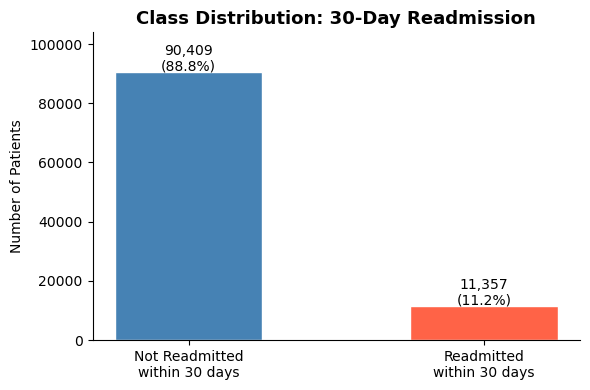

In [5]:
# ── GRAPH 1: Class Distribution (Bar Chart) ───────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['readmitted_binary'].value_counts().sort_index()
bars = ax.bar(
    ['Not Readmitted\nwithin 30 days', 'Readmitted\nwithin 30 days'],
    [counts[0], counts[1]],
    color=['steelblue', 'tomato'], edgecolor='white', width=0.5
)
for bar, count in zip(bars, [counts[0], counts[1]]):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=10)

ax.set_title('Class Distribution: 30-Day Readmission', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('graph1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/h_/qpmx4m_d139577g11qyfxcmh0000gn/T/ipykernel_6815/4057666958.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(age_stats['age'], rotation=45, ha='right')


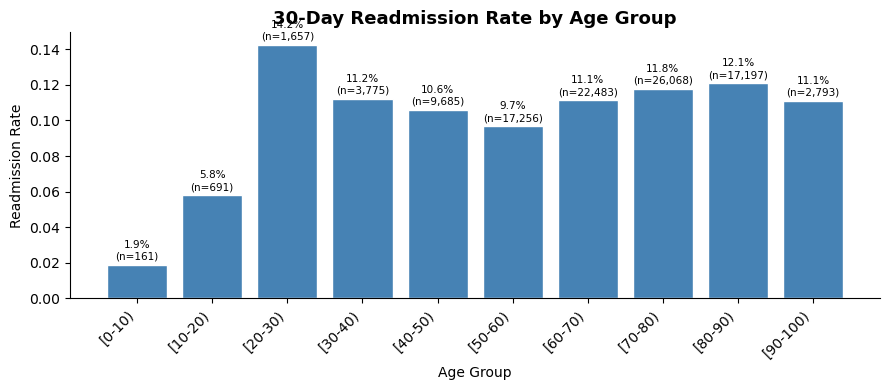

In [6]:
# ── GRAPH 2: Readmission Rate by Age Group (Bar Chart) ────────────────────
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_stats = (df.groupby('age')['readmitted_binary']
               .agg(['mean', 'count'])
               .reindex(age_order)
               .reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(age_stats['age'], age_stats['mean'],
              color='steelblue', edgecolor='white')
for bar, val, n in zip(bars, age_stats['mean'], age_stats['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.1%}\n(n={int(n):,})', ha='center', fontsize=7.5)

ax.set_title('30-Day Readmission Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Readmission Rate')
ax.set_xticks(range(len(age_stats['age'])))
ax.set_xticklabels(age_stats['age'], rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig('graph2_readmission_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

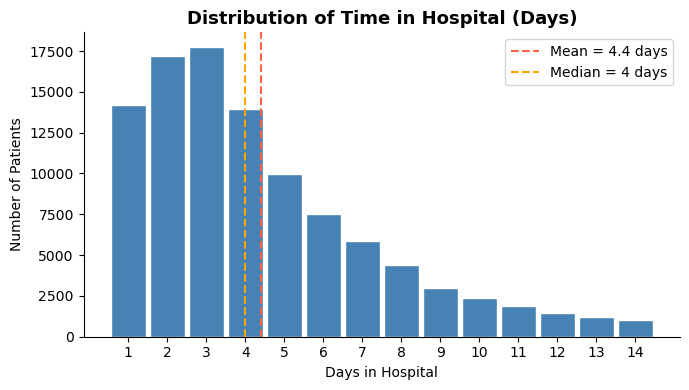

In [7]:
# ── GRAPH 3: Distribution of Time in Hospital (Histogram) ─────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['time_in_hospital'], bins=range(1, 16),
        color='steelblue', edgecolor='white', rwidth=0.9, align='left')

ax.axvline(df['time_in_hospital'].mean(), color='tomato', linestyle='--',
           linewidth=1.5, label=f"Mean = {df['time_in_hospital'].mean():.1f} days")
ax.axvline(df['time_in_hospital'].median(), color='orange', linestyle='--',
           linewidth=1.5, label=f"Median = {df['time_in_hospital'].median():.0f} days")

ax.set_title('Distribution of Time in Hospital (Days)', fontsize=13, fontweight='bold')
ax.set_xlabel('Days in Hospital')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(1, 15))
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('graph3_time_in_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

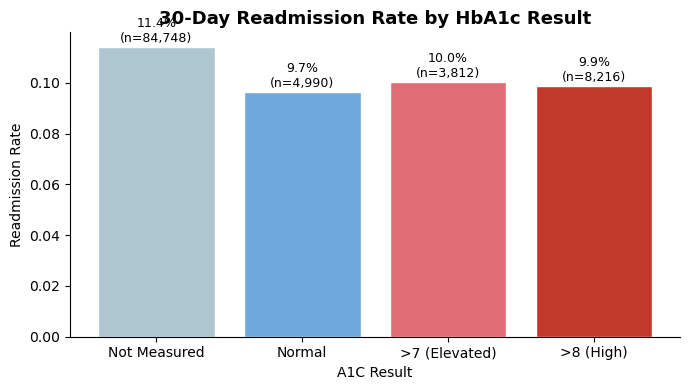

In [8]:
# ── GRAPH 4: Readmission Rate by A1C Result (Bar Chart) ──────────────────
a1c_order = ['None', 'Norm', '>7', '>8']
a1c_stats = (df.groupby('A1Cresult')['readmitted_binary']
               .agg(['mean', 'count'])
               .reindex(a1c_order)
               .reset_index())

a1c_labels = ['Not Measured', 'Normal', '>7 (Elevated)', '>8 (High)']
colors = ['#aec6cf', '#6fa8dc', '#e06c75', '#c0392b']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(a1c_labels, a1c_stats['mean'], color=colors, edgecolor='white')
for bar, val, n in zip(bars, a1c_stats['mean'], a1c_stats['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.1%}\n(n={int(n):,})', ha='center', fontsize=9)

ax.set_title('30-Day Readmission Rate by HbA1c Result', fontsize=13, fontweight='bold')
ax.set_xlabel('A1C Result')
ax.set_ylabel('Readmission Rate')
sns.despine()
plt.tight_layout()
plt.savefig('graph4_readmission_by_a1c.png', dpi=150, bbox_inches='tight')
plt.show()

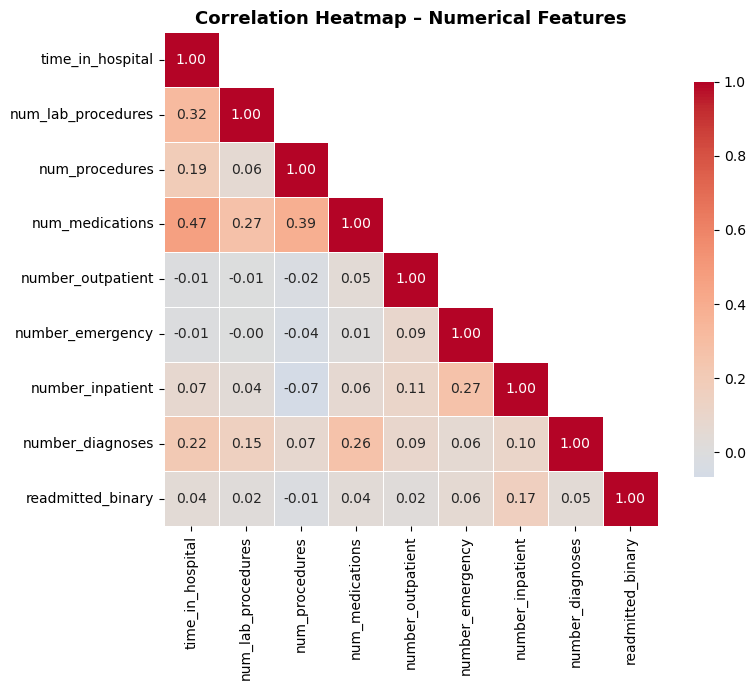

In [9]:
# ── GRAPH 5: Correlation Heatmap (Numerical Features) ────────────────────
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'readmitted_binary']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap \u2013 Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()